In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
G = nx.read_edgelist("facebook_combined.txt", delimiter=" ")
# nx.draw(G,node_size=1, width=0.15)

(array([3.59e+03, 4.26e+02, 1.80e+01, 1.00e+00, 0.00e+00, 1.00e+00,
        0.00e+00, 2.00e+00, 0.00e+00, 1.00e+00]),
 array([1.000e+00, 1.054e+02, 2.098e+02, 3.142e+02, 4.186e+02, 5.230e+02,
        6.274e+02, 7.318e+02, 8.362e+02, 9.406e+02, 1.045e+03]),
 <BarContainer object of 10 artists>)

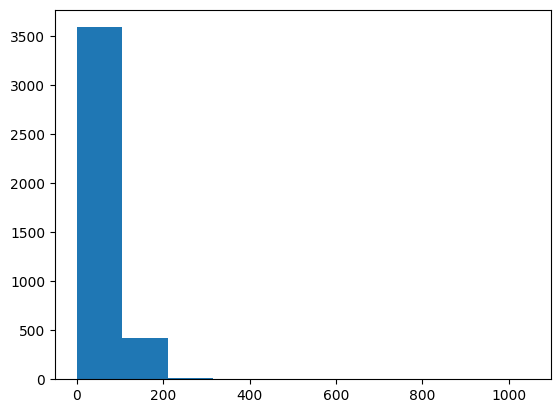

In [4]:
deg_view_G = nx.degree(G)
deg_vals = dict(deg_view_G).values()
plt.hist(deg_vals)

1 1045
[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  119  120  121  122  123  124  125  126  127
  128  129  130  131  132  133  134  135  136  137  138  139  140  141
  142  144  145  146  147  148  149  150  151  152  153  154  155  156
  157  158  159  160  161  162  163  164  165  166  167  168  169  170
  171  172  173  174  175  176  177  178  179  180  181  182  183  184
  185  186  187  188  189  190  191  192  193  194  195  196  197  198

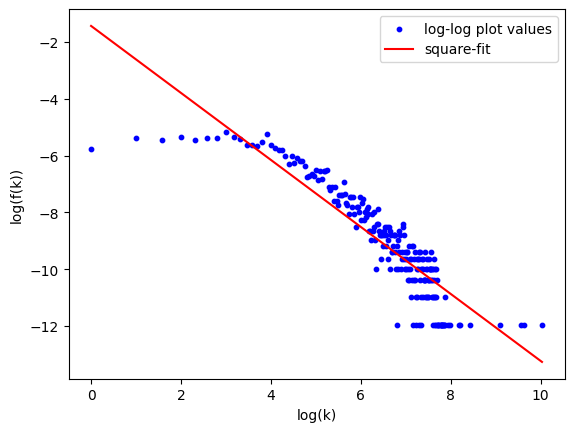

In [5]:
min_deg = min(deg_vals)
max_deg = max(deg_vals)
print(min_deg, max_deg)
n = G.number_of_nodes()
x_vals = np.sort(np.unique(list(deg_vals)))
print(x_vals)
y_vals = [list(deg_vals).count(i)/n for i in x_vals]
marker_size = 10
# print(y_vals)
y_log_vals = np.log2(y_vals)
y_log_vals
x_log_vals = np.log2(x_vals)
plt.scatter(x_log_vals, y_log_vals, c='blue', s=marker_size, label='log-log plot values')
# print(y_log_vals)
m, b = np.polyfit(x_log_vals, y_log_vals, 1)  # Ordinary Least Squares (OLS) method to find the best fit for your data.

plt.plot(x_log_vals, m*x_log_vals + b, label='square-fit', c='red')
plt.xlabel("log(k)")
plt.ylabel("log(f(k))")
plt.legend()

In [6]:
predicted = m*x_log_vals + b
SS_res = np.sum((y_log_vals - predicted) ** 2)  # Residual sum of squares
SS_tot = np.sum((y_log_vals - np.mean(y_log_vals)) ** 2)  # Total sum of squares
R2 = 1 - (SS_res / SS_tot)
R2

np.float64(0.8091782885710821)

[ 9.81431047e-01  9.57167616e-01  9.34142114e-01  9.09631097e-01
  8.86605595e-01  8.62342164e-01  8.38078732e-01  8.10596682e-01
  7.85838079e-01  7.62317405e-01  7.42262936e-01  7.21960881e-01
  7.02401585e-01  6.80861599e-01  6.54617480e-01  6.34315425e-01
  6.15498886e-01  5.97425105e-01  5.79598911e-01  5.64000990e-01
  5.51126516e-01  5.35528596e-01  5.22406536e-01  5.07551374e-01
  4.93934142e-01  4.80069324e-01  4.67937608e-01  4.58776925e-01
  4.49368656e-01  4.39465214e-01  4.30056945e-01  4.19163159e-01
  4.10497648e-01  3.99851448e-01  3.90938351e-01  3.80292152e-01
  3.69645952e-01  3.58752166e-01  3.51572171e-01  3.44887348e-01
  3.37707353e-01  3.32508047e-01  3.25328051e-01  3.20128745e-01
  3.15424610e-01  3.09482545e-01  3.03540480e-01  2.97598415e-01
  2.89428076e-01  2.83238425e-01  2.78286705e-01  2.73582570e-01
  2.69868779e-01  2.64174301e-01  2.58479822e-01  2.54023273e-01
  2.48328794e-01  2.44615004e-01  2.41891557e-01  2.37435009e-01
  2.32978460e-01  2.29017

C:\Users\z72w146\AppData\Local\Temp\ipykernel_22520\1915756268.py:6: RuntimeWarning: invalid value encountered in log2
  log_pref_sum = np.log2(one_minus_pref_sum)


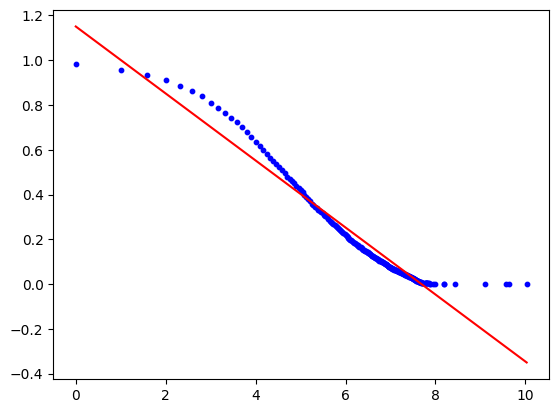

In [7]:
prefix_sum = np.cumsum(y_vals)
# print(prefix_sum)
one_minus_pref_sum = 1-prefix_sum/sum(y_vals)
print(one_minus_pref_sum)
# print(y_vals)
log_pref_sum = np.log2(one_minus_pref_sum)
print(log_pref_sum)
plt.scatter(x_log_vals, one_minus_pref_sum, c='blue', s=marker_size, label='log-log plot F^c(k)')
# print(one_minus_pref_sum)

m, b = np.polyfit(x_log_vals, one_minus_pref_sum, 1)  # Ordinary Least Squares (OLS) method to find the best fit for your data.
plt.plot(x_log_vals, m*x_log_vals + b, label='square-fit', c='red')